# 02 - Baseline CNN

This notebook trains and evaluates a custom Convolutional Neural Network from scratch using the fixed 70/15/15 dataset split created in `01_dataset_preparation.ipynb`.

The baseline model will later be compared fairly against MobileNetV2 and ResNet18 using the same test set.

In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

TRAIN_DIR = PROJECT_DIR / "dataset" / "split" / "train"
VAL_DIR = PROJECT_DIR / "dataset" / "split" / "validation"
TEST_DIR = PROJECT_DIR / "dataset" / "split" / "test"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results" / "baseline"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train exists: True
Validation exists: True
Test exists: True


In [7]:
# Importing Libraries
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [8]:
# Setting the randome seed
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Defining preprocessing
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# Here using Grayscale because NEU images are grayscale
# but later MobileNetV2 and ResNet18 expect 3-channel input
# Therefore using 3 channels here keeps preprocessing more
# consistent.

In [9]:
# Loading the datasets
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}
Training images: 1260
Validation images: 270
Test images: 270


In [10]:
# Create Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [12]:
# Building the baseline CNN
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=6):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                128
            ),

            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = BaselineCNN(
    num_classes=len(train_dataset.classes)
).to(device)

print(model)
print("Device:", device)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)
Device: cuda


In [13]:
# Defining training settings
LEARNING_RATE = 0.001
EPOCHS = 5

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [14]:
# Creating training history
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [15]:
# Training the model
best_val_accuracy = 0.0

training_start = time.time()

for epoch in range(EPOCHS):

    # ---------------------
    # Training
    # ---------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataset)

    train_accuracy = (
        100 * correct / total
    )

    # ---------------------
    # Validation
    # ---------------------

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_dataset)
    )

    val_accuracy = (
        100 * val_correct /
        val_total
    )

    # Save history

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

    # Save best model

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            MODELS_DIR /
            "baseline_cnn.pth"
        )

training_time = (
    time.time() - training_start
)

print(
    f"\nTraining completed in "
    f"{training_time:.2f} seconds"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

Epoch [1/5] | Train Loss: 1.2407 | Train Acc: 52.62% | Val Loss: 0.5525 | Val Acc: 80.00%
Epoch [2/5] | Train Loss: 0.6526 | Train Acc: 76.35% | Val Loss: 0.3231 | Val Acc: 89.63%
Epoch [3/5] | Train Loss: 0.3568 | Train Acc: 87.62% | Val Loss: 0.3479 | Val Acc: 85.56%
Epoch [4/5] | Train Loss: 0.3227 | Train Acc: 86.98% | Val Loss: 0.2444 | Val Acc: 90.74%
Epoch [5/5] | Train Loss: 0.2013 | Train Acc: 92.54% | Val Loss: 0.1240 | Val Acc: 95.56%

Training completed in 455.56 seconds
Best validation accuracy: 95.56%


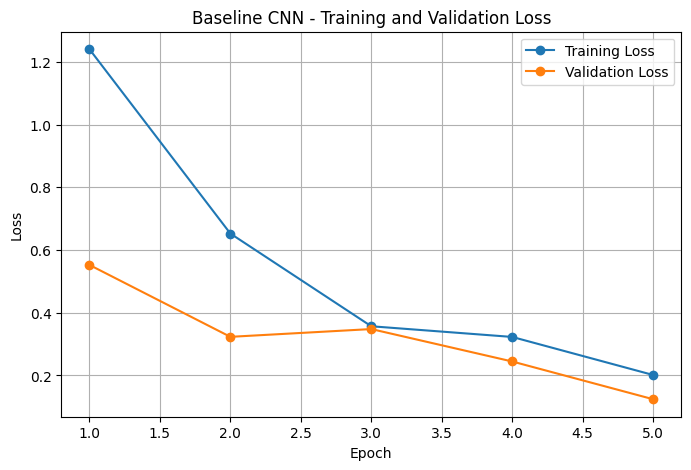

In [16]:
# Potting training curves
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR /
    "training_loss_curve.png",
    bbox_inches="tight"
)

plt.show()

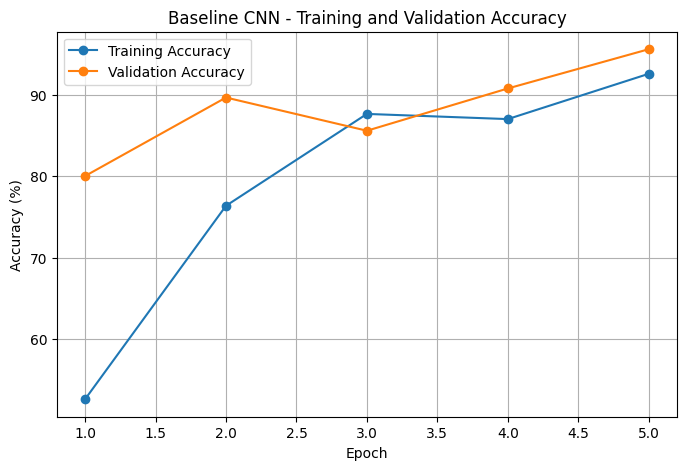

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR /
    "training_accuracy_curve.png",
    bbox_inches="tight"
)

plt.show()

In [18]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /
        "baseline_cnn.pth",
        map_location=device
    )
)

model.eval()

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [19]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

In [20]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{precision * 100:.2f}%"
)

print(
    f"Macro Recall: "
    f"{recall * 100:.2f}%"
)

print(
    f"Macro F1 Score: "
    f"{f1 * 100:.2f}%"
)

Test Accuracy: 94.44%
Macro Precision: 94.45%
Macro Recall: 94.44%
Macro F1 Score: 94.42%


In [21]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
)

print(report)

                 precision    recall  f1-score   support

        crazing       0.96      0.96      0.96        45
      inclusion       0.93      0.96      0.95        45
        patches       0.91      0.96      0.93        45
 pitted_surface       0.91      0.87      0.89        45
rolled_in_scale       0.98      1.00      0.99        45
      scratches       0.98      0.93      0.95        45

       accuracy                           0.94       270
      macro avg       0.94      0.94      0.94       270
   weighted avg       0.94      0.94      0.94       270



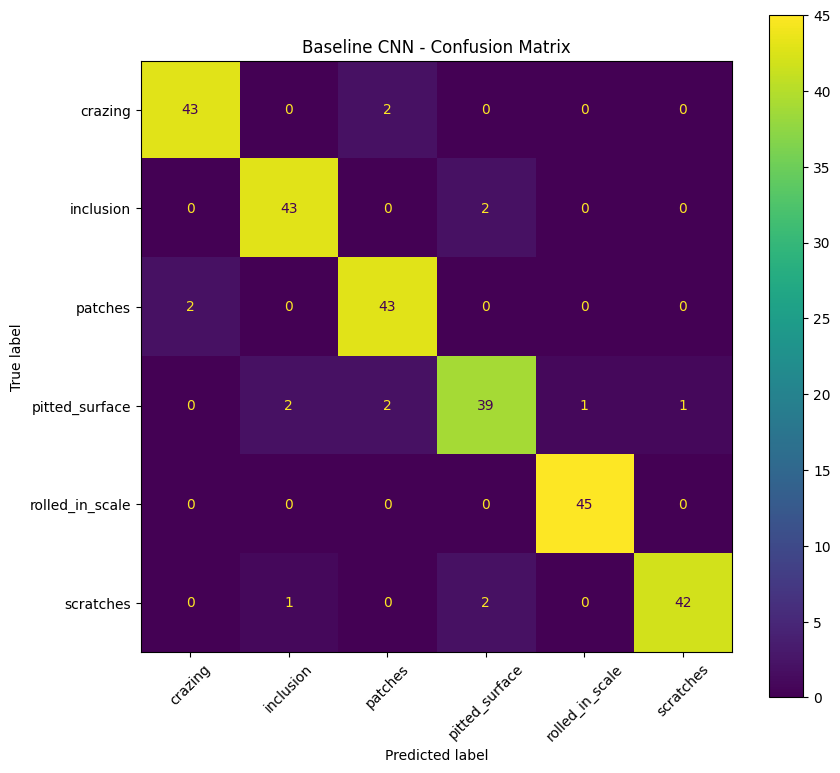

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Baseline CNN - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
metrics_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "test_accuracy": test_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "best_validation_accuracy":
            best_val_accuracy / 100,
        "epochs": EPOCHS,
        "training_time_seconds":
            training_time
    }
])

display(metrics_df)

metrics_df.to_csv(
    RESULTS_DIR /
    "metrics.csv",
    index=False
)

,model,test_accuracy,macro_precision,macro_recall,macro_f1,best_validation_accuracy,epochs,training_time_seconds
0,Baseline CNN,0.944444,0.944536,0.944444,0.944219,0.955556,5,455.562564


Number of test errors: 15


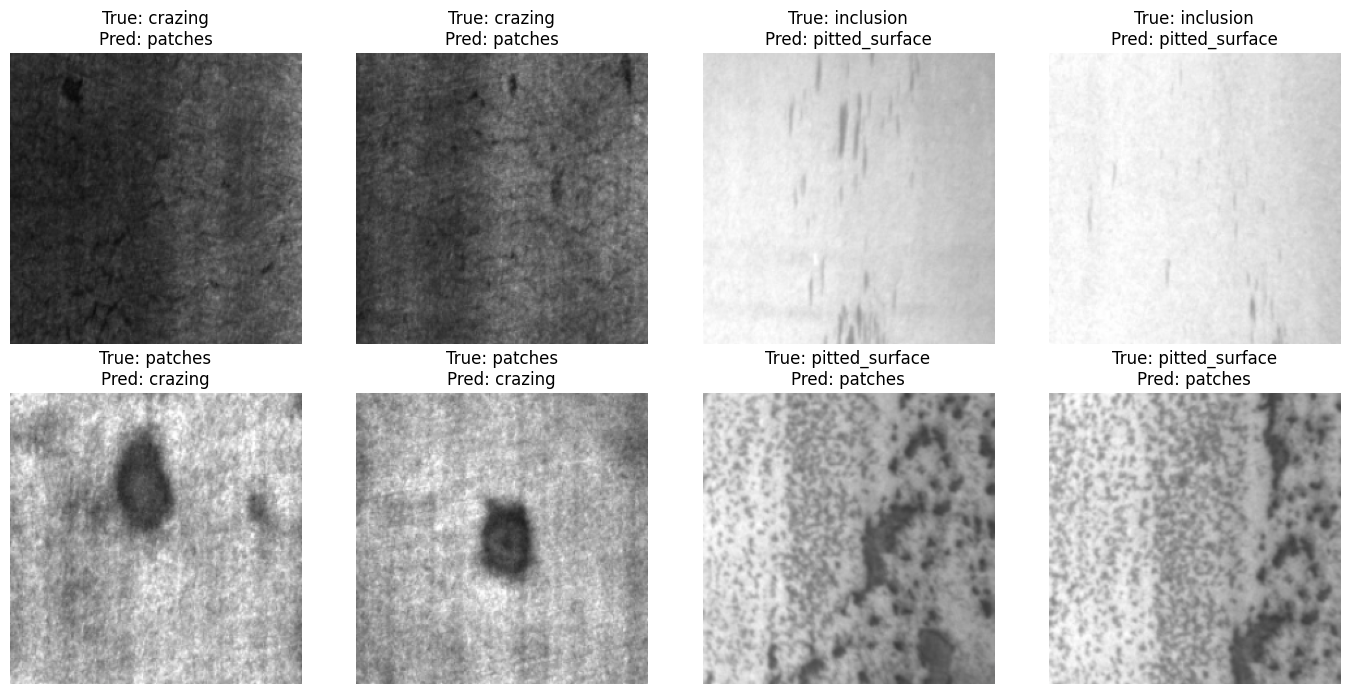

In [24]:
# Failure case visualization
failure_indices = [
    i
    for i, (true, pred)
    in enumerate(
        zip(
            all_labels,
            all_predictions
        )
    )
    if true != pred
]

print(
    "Number of test errors:",
    len(failure_indices)
)

class_names = test_dataset.classes

num_to_show = min(
    8,
    len(failure_indices)
)

plt.figure(figsize=(14, 7))

for plot_index, error_index in enumerate(
    failure_indices[:num_to_show]
):

    image, true_label = (
        test_dataset[error_index]
    )

    image_for_display = (
        image.permute(1, 2, 0)
        .numpy()
    )

    # Undo normalization approximately

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image_for_display = (
        image_for_display * std + mean
    )

    image_for_display = np.clip(
        image_for_display,
        0,
        1
    )

    predicted_label = (
        all_predictions[error_index]
    )

    plt.subplot(
        2,
        4,
        plot_index + 1
    )

    plt.imshow(image_for_display)

    plt.title(
        f"True: "
        f"{class_names[true_label]}\n"
        f"Pred: "
        f"{class_names[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "failure_cases.png",
    bbox_inches="tight"
)

plt.show()

## Baseline CNN Summary

The custom CNN was trained from scratch using the common 70/15/15 dataset split.

The model was evaluated on the untouched test set using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Confusion Matrix
- Failure-case analysis

These results will be used as the controlled baseline for comparison with MobileNetV2 and ResNet18.